# GraphGenerator on ZINC

This notebook demonstrates the two-stage `GraphGenerator`: first generate a new interpretation graph, then instantiate base molecules conditionally from nearby ZINC examples.

In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from collections import Counter

from nsppk import NSPPK
from sklearn.ensemble import RandomForestClassifier

from abstractgraph.display import display, display_decomposition_graph, display_mappings
from abstractgraph.graphs import graph_to_abstract_graph
from abstractgraph.operators import *
from abstractgraph_graphicalizer.chem import ZINCLoader, draw_molecules as display_graphs
from abstractgraph_ml.estimators import GraphEstimator
from abstractgraph_generative.conditional import ConditionalAutoregressiveGenerator
from abstractgraph_generative.edge_generator import EdgeGenerator
from abstractgraph_generative.graph_generator import GraphGenerator


In [3]:
loader = ZINCLoader(on_error="skip")

dataset_name = "zinc_250k"
size = 1280
min_num_nodes = 15
max_num_nodes = 20

graphs, metadata = loader.load(
    dataset_name,
    limit=size,
    min_node_count=min_num_nodes,
    max_node_count=max_num_nodes,
)

print(f"dataset: {dataset_name}")
print(f"n_graphs: {len(graphs)}")
print(f"node_range: [{min_num_nodes}, {max_num_nodes}]")


dataset: zinc_250k
n_graphs: 1280
node_range: [15, 20]


In [4]:
cycle_tree = add(
    compose(name("cycle"), cycle()),
    compose(name("tree"), tree()),
)
decomposition_function = compose(intersection_edges(), cycle_tree)
nbits = 14
label_mode = "histogram_values"

interpretation_graphs = [
    graph_to_abstract_graph(
        graph,
        decomposition_function=decomposition_function,
        nbits=nbits,
        label_mode=label_mode,
    ).interpretation_graph.copy()
    for graph in graphs
]

def label_counts(graph):
    return Counter(data.get("label") for _, data in graph.nodes(data=True))

class AlwaysFeasible:
    def fit(self, graphs):
        return self

    def predict(self, graphs):
        return [1] * len(graphs)

def draw(graph, decomposition_function, *, nbits=11, label_mode="operator_hash", size=(12, 6), n_elements_per_row=8):
    display_decomposition_graph(decomposition_function)
    ag = graph_to_abstract_graph(
        graph,
        decomposition_function=decomposition_function,
        nbits=nbits,
        label_mode=label_mode,
    )
    display(ag, size=size)
    display_mappings(ag, n_elements_per_row=n_elements_per_row)
    return ag

print("first interpretation label counts:", label_counts(interpretation_graphs[0]))


first interpretation label counts: Counter({16029: 2, 13302: 1, 16275: 1})


In [5]:
edge_vectorizer = NSPPK(radius=1, distance=3, connector=1, nbits=12, dense=True, parallel=True)
edge_graph_estimator = GraphEstimator(
    transformer=edge_vectorizer,
    estimator=RandomForestClassifier(
        n_estimators=80,
        random_state=0,
        n_jobs=-1,
        class_weight="balanced_subsample",
    ),
)

interpretation_feasibility = AlwaysFeasible()

edge_generator = EdgeGenerator(
    partial_feasibility_estimator=interpretation_feasibility,
    final_feasibility_estimator=interpretation_feasibility,
    graph_estimator=edge_graph_estimator,
    n_negative_per_positive=3,
    n_replicates=2,
    beam_size=3,
    max_restarts=2,
    fit_n_jobs=-1,
    fit_backend="loky",
    seed=0,
)

conditional_vectorizer = NSPPK(radius=1, distance=4, connector=1, nbits=14, dense=True, parallel=True)
conditional_generator = ConditionalAutoregressiveGenerator(
    decomposition_function=decomposition_function,
    nbits=nbits,
    label_mode=label_mode,
    base_cut_radius=0,
    interpretation_cut_radius=1,
    context_vectorizer=conditional_vectorizer,
    n_jobs=1,
    debug=False,
)

generator = GraphGenerator(
    edge_generator=edge_generator,
    conditional_generator=conditional_generator,
    decomposition_function=decomposition_function,
    nbits=nbits,
    label_mode=label_mode,
    interpretation_neighbor_vectorizer=NSPPK(radius=1, distance=3, connector=1, nbits=12, dense=True, parallel=True),
    seed=0,
)
generator.store(graphs, interpretation_graphs=interpretation_graphs)


generated molecules: 2
seed indices: [663, 808]


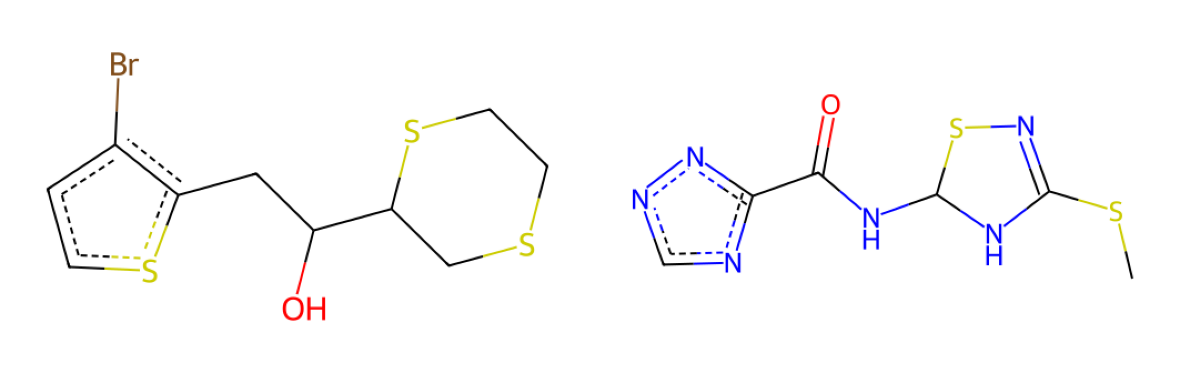

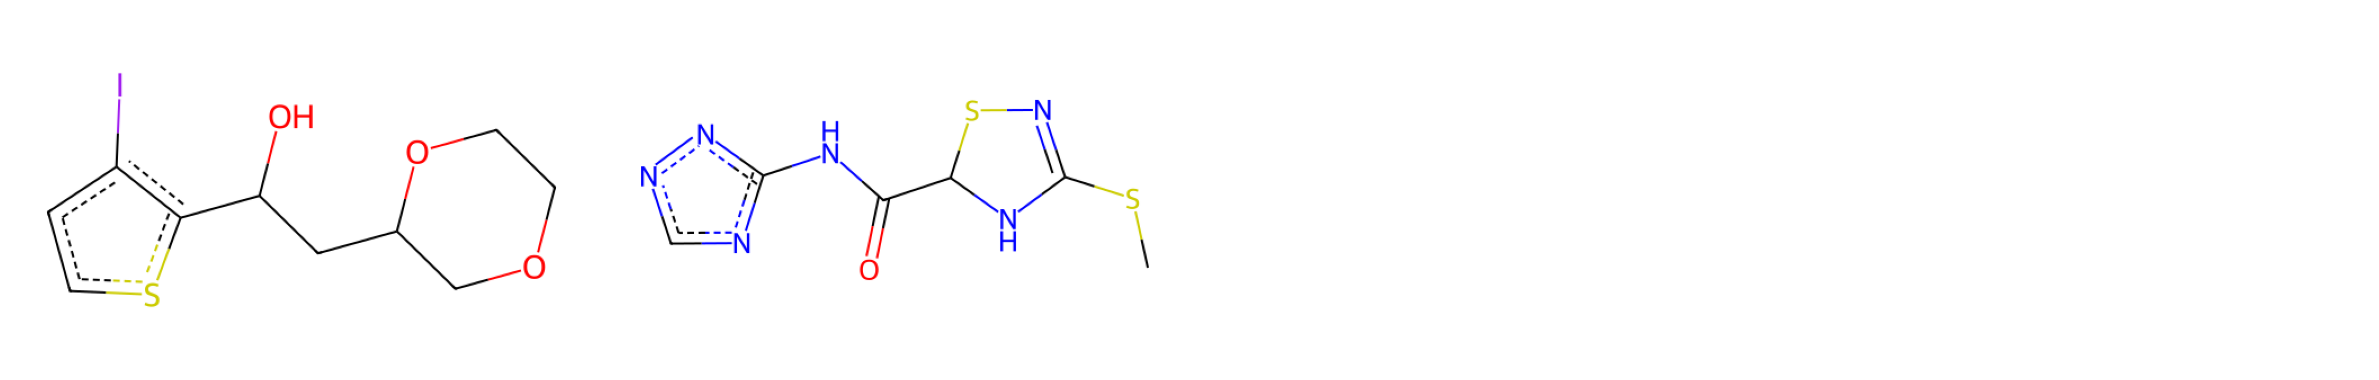

In [9]:
generated_graphs = generator.sample(
    n_samples=2,
    n_interpretation_neighbors=240,
    n_conditional_neighbors=240,
    n_instances_per_sample=1,
    interpretation_edge_removal_size=0.35,
    random_state=7,
    conditional_generate_kwargs=dict(
        random_state=7,
        max_backtracks=2000,
        max_attempts_per_sample=6,
        require_signature_coverage=True,
    ),
)

print(f"generated molecules: {len(generated_graphs)}")
print("seed indices:", generator.last_sampled_indices_)
display_graphs([graphs[i] for i in generator.last_sampled_indices_], n_graphs_per_line=2)
if generated_graphs:
    display_graphs(generated_graphs, n_graphs_per_line=4)
else:
    print("No molecules generated; inspect warnings and try a larger neighborhood or dataset slice.")


generated molecule 0


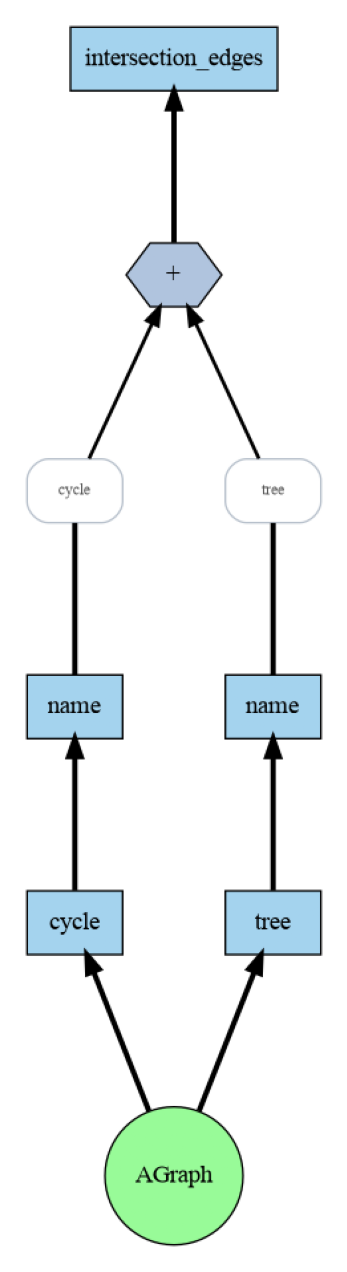

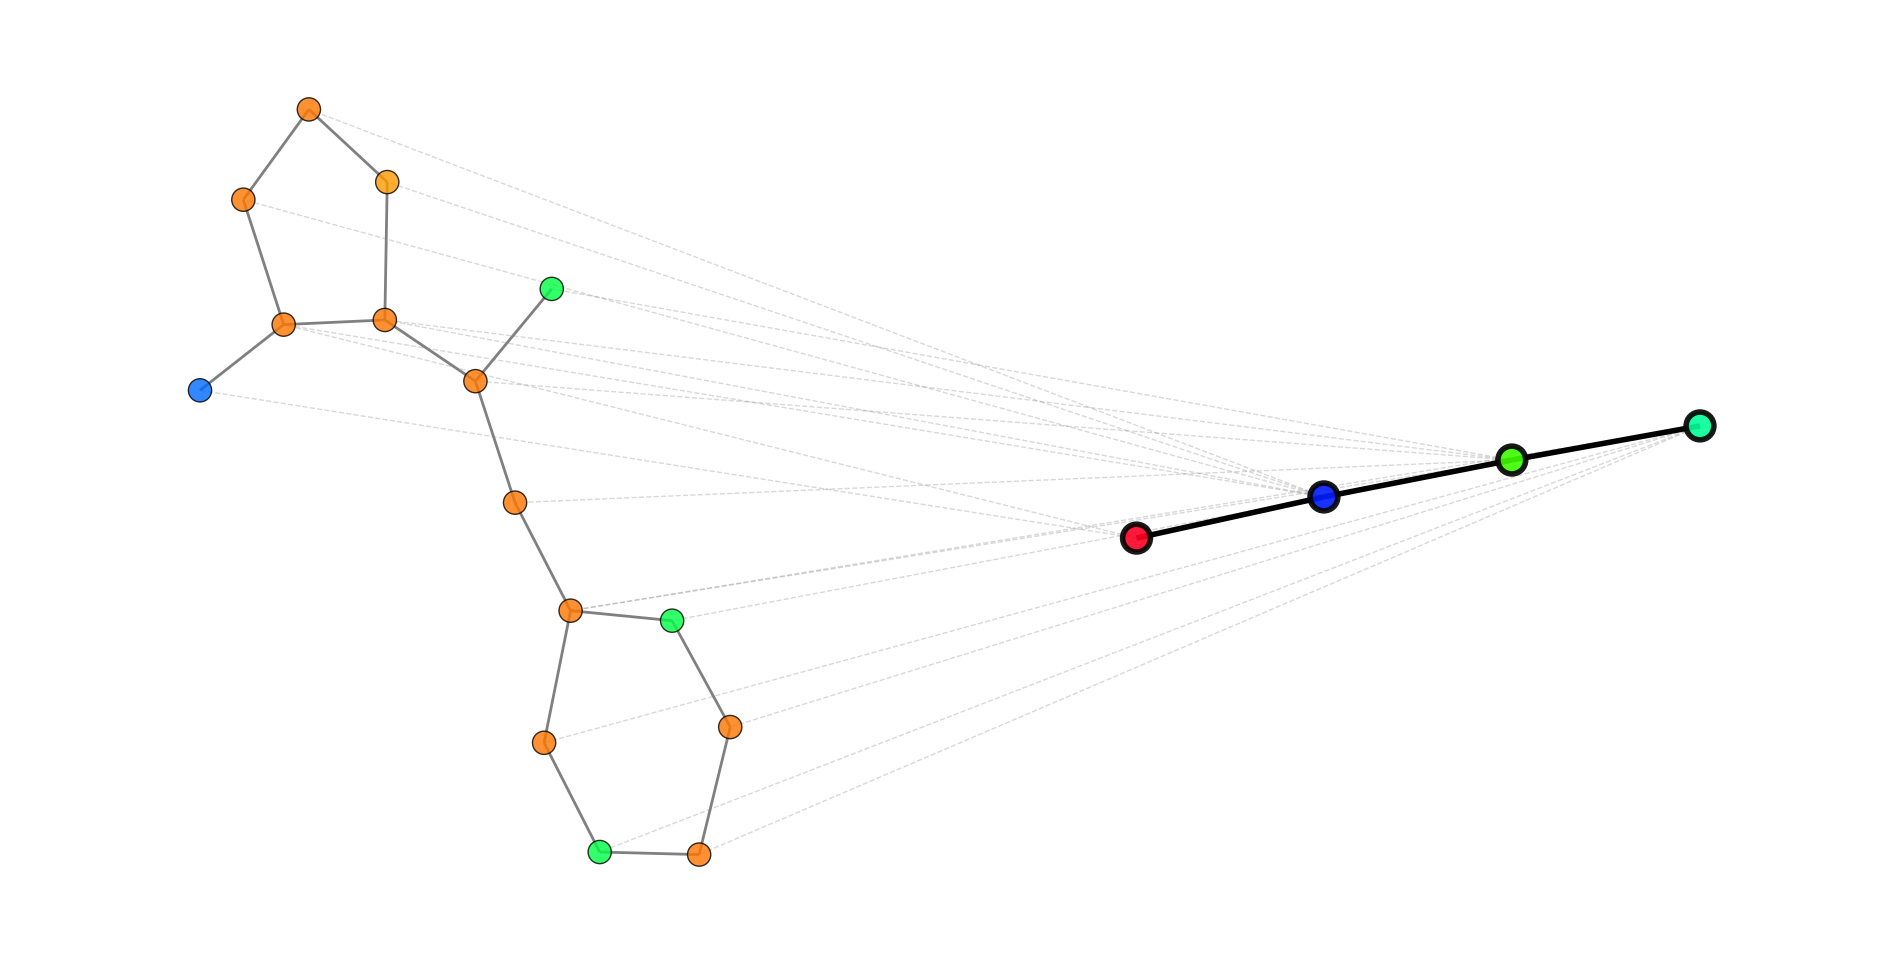

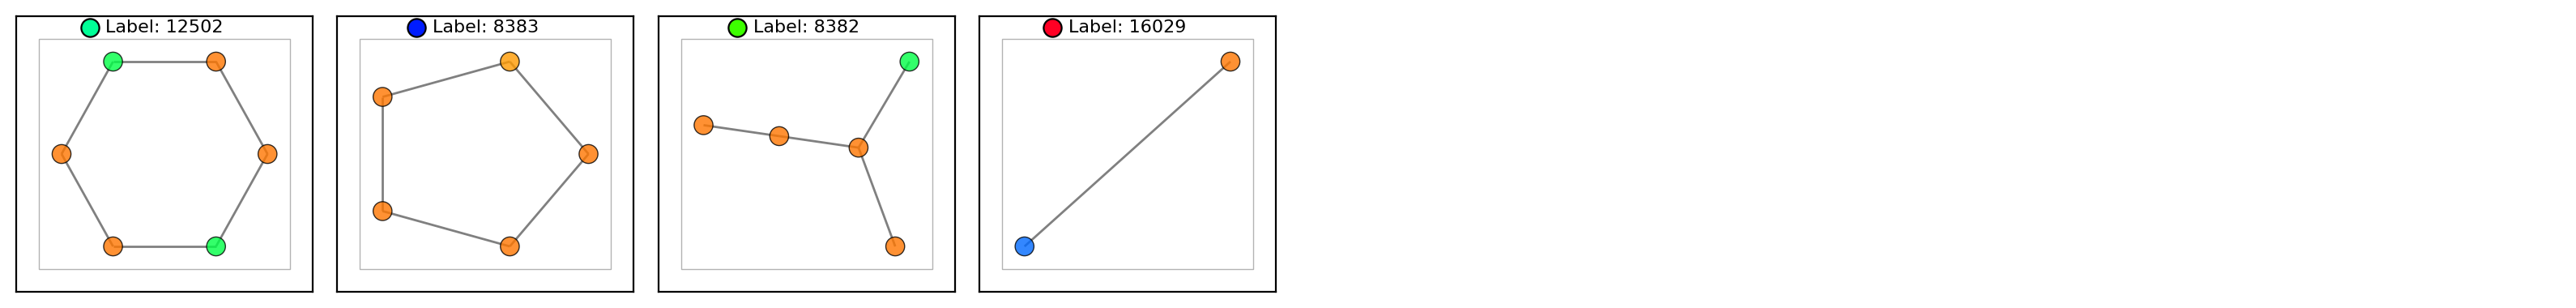

generated molecule 1


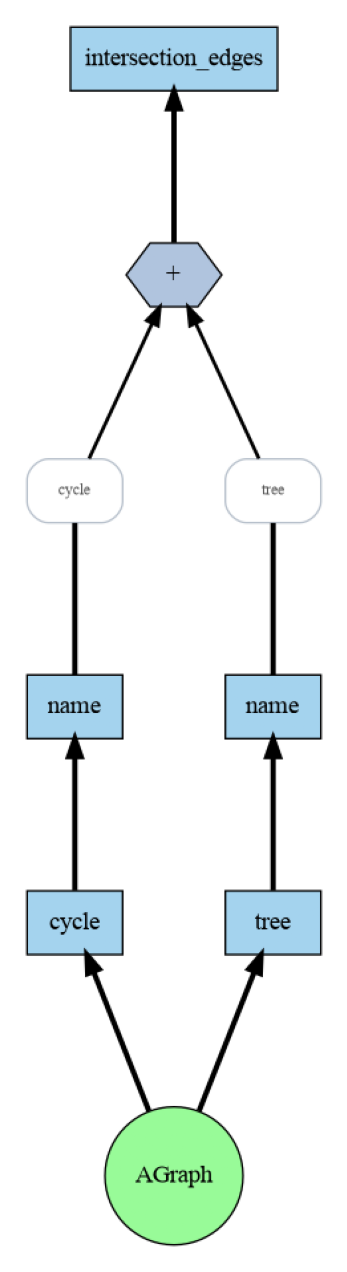

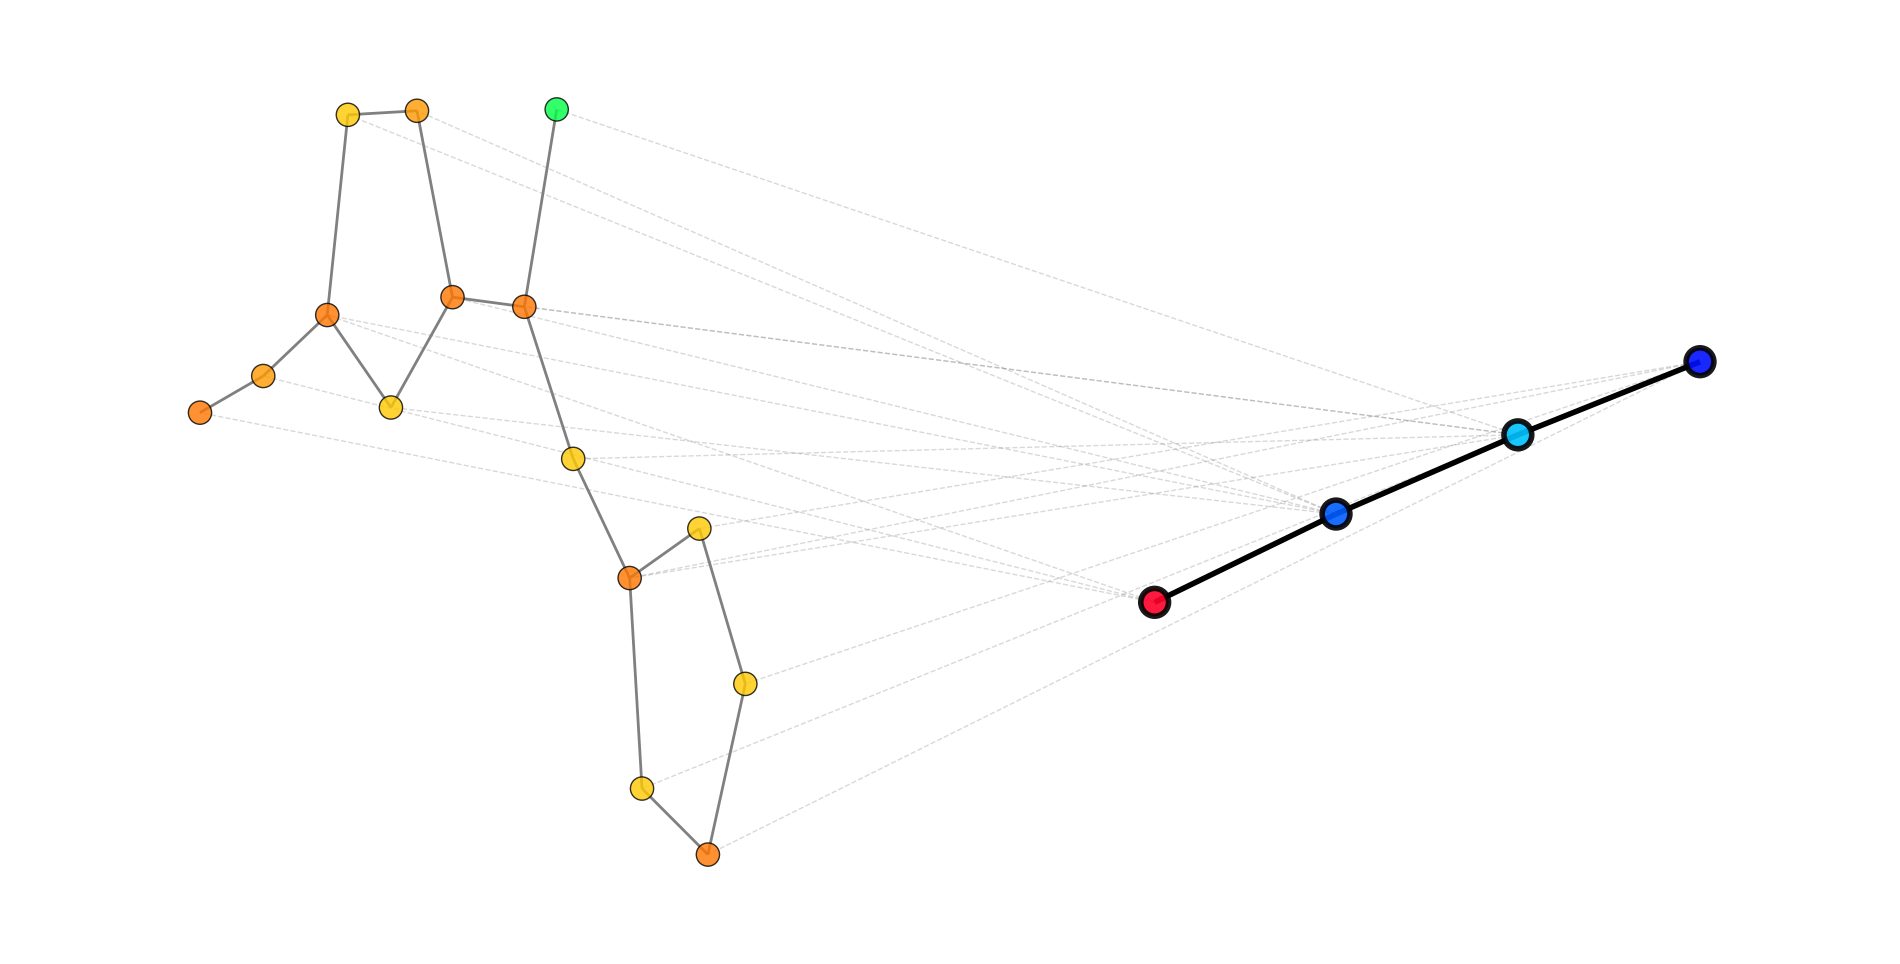

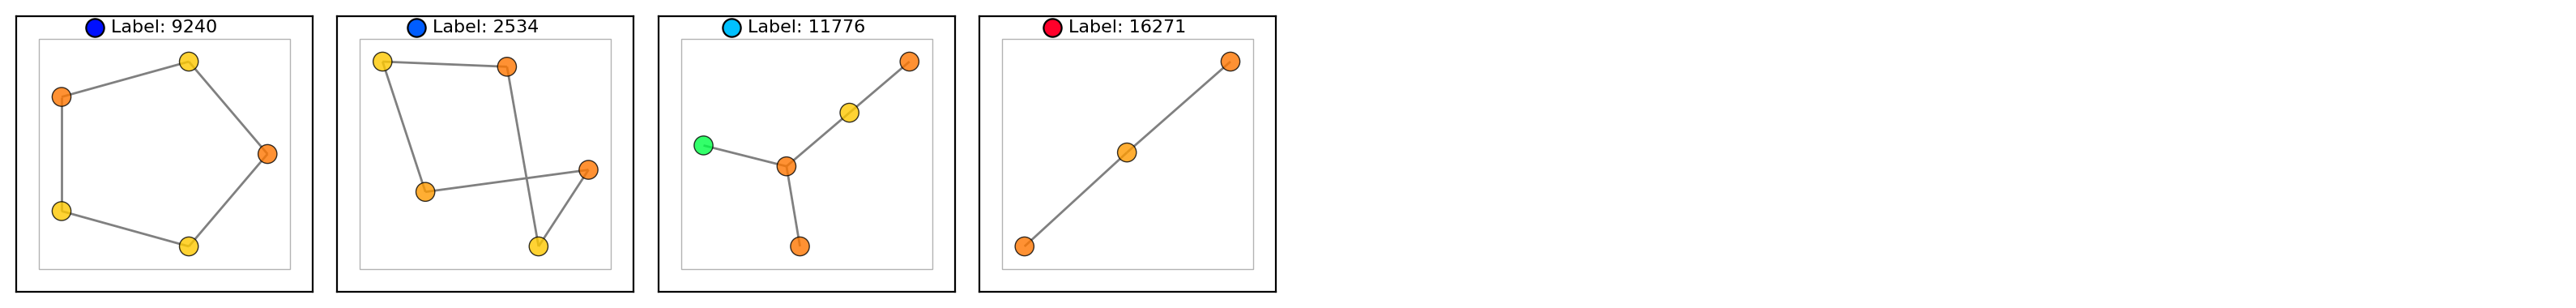

In [10]:
generated_abstract_graphs = []
if not generated_graphs:
    print("No generated molecules to decompose and display.")
else:
    for i, graph in enumerate(generated_graphs):
        print(f"generated molecule {i}")
        generated_abstract_graphs.append(
            draw(
                graph,
                decomposition_function,
                nbits=nbits,
                label_mode=label_mode,
                size=(12, 6),
                n_elements_per_row=8,
            )
        )


In [11]:
rows = []
for sample_id, target_graph in enumerate(generator.last_generated_interpretation_graphs_):
    seed_idx = generator.last_sampled_indices_[sample_id]
    seed_counts = label_counts(generator.stored_interpretation_graphs_[seed_idx])
    target_counts = label_counts(target_graph)
    for instance_id, generated_graph in enumerate(generated_graphs[sample_id * 2:(sample_id + 1) * 2]):
        final_interpretation = graph_to_abstract_graph(
            generated_graph,
            decomposition_function=decomposition_function,
            nbits=nbits,
            label_mode=label_mode,
        ).interpretation_graph
        rows.append({
            "sample": sample_id,
            "instance": instance_id,
            "seed_counts": seed_counts,
            "target_counts": target_counts,
            "final_counts": label_counts(final_interpretation),
        })

rows


[{'sample': 0,
  'instance': 0,
  'seed_counts': Counter({12502: 1, 8383: 1, 8382: 1, 16029: 1}),
  'target_counts': Counter({12502: 1, 8383: 1, 8382: 1, 16029: 1}),
  'final_counts': Counter({12502: 1, 8383: 1, 8382: 1, 16029: 1})},
 {'sample': 0,
  'instance': 1,
  'seed_counts': Counter({12502: 1, 8383: 1, 8382: 1, 16029: 1}),
  'target_counts': Counter({12502: 1, 8383: 1, 8382: 1, 16029: 1}),
  'final_counts': Counter({9240: 1, 2534: 1, 11776: 1, 16271: 1})}]